In [13]:
import pandas as pd

df = pd.read_csv("../data/Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [14]:
df.shape

(14640, 15)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [16]:
df["airline_sentiment"].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [17]:
df = df[["text", "airline_sentiment"]]

In [18]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [19]:
df.shape

(14640, 2)

In [20]:
df["airline_sentiment"].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

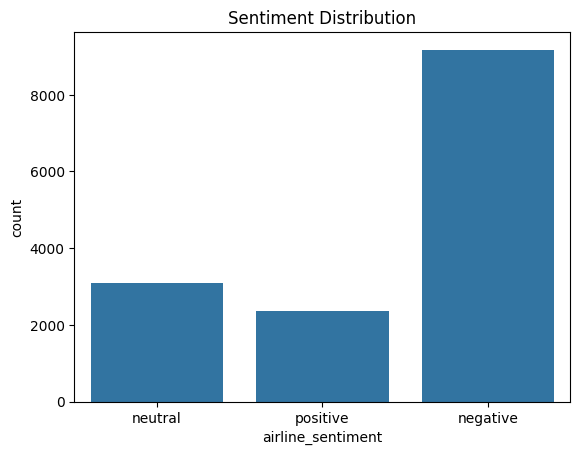

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="airline_sentiment"
)

plt.title("Sentiment Distribution")
plt.show()

In [22]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [23]:
df["clean_text"] = df["text"].apply(clean_text)

In [24]:
df[
    ["text", "clean_text"]
].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,virginamerica what dhepburn said
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercials to ...
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica i didnt today must mean i need t...
3,@VirginAmerica it's really aggressive to blast...,virginamerica its really aggressive to blast o...
4,@VirginAmerica and it's a really big bad thing...,virginamerica and its a really big bad thing a...


In [25]:
X = df["clean_text"]
y = df["airline_sentiment"]

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [27]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, stop_words="english")


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

In [30]:
X_train_tfidf.shape

(11712, 50000)

In [31]:
X_test_tfidf.shape

(2928, 50000)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [34]:
y_pred = model.predict(
    X_test_tfidf
)

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7742486338797814


In [37]:
from sklearn.metrics import classification_report

In [38]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.82      0.86      1835
     neutral       0.57      0.67      0.62       620
    positive       0.67      0.72      0.70       473

    accuracy                           0.77      2928
   macro avg       0.71      0.74      0.72      2928
weighted avg       0.79      0.77      0.78      2928



In [39]:
from sklearn.metrics import confusion_matrix

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1510  228   97]
 [ 137  415   68]
 [  47   84  342]]


In [41]:
sample = [
    "The flight was amazing and the staff were very helpful"
]

sample_vector = tfidf.transform(sample)

model.predict(sample_vector)

array(['positive'], dtype=object)

In [42]:
sample = [
    "Worst airline experience ever"
]

sample_vector = tfidf.transform(sample)

model.predict(sample_vector)

array(['negative'], dtype=object)

In [43]:
sample = ["Amazing customer service and friendly staff"]
sample_vector = tfidf.transform(sample)
model.predict(sample_vector)

array(['positive'], dtype=object)

In [44]:
sample = ["Worst airline experience ever, very disappointed"]
sample_vector = tfidf.transform(sample)
model.predict(sample_vector)

array(['negative'], dtype=object)

In [45]:
model.predict(
    tfidf.transform(
        ["Thank you for the excellent service and smooth flight"]
    )
)

array(['positive'], dtype=object)

In [46]:
model.predict(
    tfidf.transform(
        ["My flight was cancelled and customer support was terrible"]
    )
)

array(['negative'], dtype=object)

In [47]:
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.7742486338797814
              precision    recall  f1-score   support

    negative       0.89      0.82      0.86      1835
     neutral       0.57      0.67      0.62       620
    positive       0.67      0.72      0.70       473

    accuracy                           0.77      2928
   macro avg       0.71      0.74      0.72      2928
weighted avg       0.79      0.77      0.78      2928



In [48]:
import pickle

In [49]:
with open("../models/sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [50]:
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [51]:
import os

os.listdir("../models")

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']